In [1]:
from pathlib import Path
from typing import Tuple

import cv2 
import numpy as np
import matplotlib.pyplot as plt
from numpy.lib.stride_tricks import sliding_window_view
from tqdm import tqdm
import math

### Watch the videos

In [2]:
input_dir = Path('input')
pedestrians_path = str(input_dir / 'pedestrians.avi')
debate_path = str(input_dir / 'pres_debate.avi')
noisy_debate_path = str(input_dir / 'noisy_debate.avi')
pres_debate_hand_path = str(input_dir / 'pres_debate_hand.avi')

In [3]:
def get_video_frames(video_path, gray=True):
    video = cv2.VideoCapture(video_path)
    frames = []
    while True:
        ret, frame = video.read()
        if not ret:
            break
        if gray:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        # frame = cv2.cvtColor(frame, cv2.COLOR_GRAY2RGB)
        frames.append(frame)
    video.release()
    return frames


def get_initial_box(video_path):
    box_path = video_path[:-3] + "txt"  
    with open(box_path, 'r') as f:
        lines = f.readlines()
        data = []
        for line in lines:
            numbers = list(map(lambda x: int(float(x)), line.split()))
            data.append(numbers)


    return {"x": data[0][0], "y": data[0][1], "w": data[1][0], "h": data[1][1]}

def show_video(video_path):
    video = cv2.VideoCapture(video_path)
    while True:
        ret, frame = video.read()
        if not ret:
            break
        cv2.imshow('Frame', frame)
        # Press Q on keyboard to exit the display window
        if cv2.waitKey(25) & 0xFF == ord('q'):
            break
    video.release()
    cv2.destroyAllWindows()

In [4]:
def draw_bounding_box(img, center_x, center_y,w,h, color=(255,0,0)):
    img = img.copy()
    top_left = (center_x-w//2,center_y-h//2)
    bottom_right = (center_x+w//2 + 1, center_y+h//2 + 1)
    
    center = (center_x, center_y)
    if len(img.shape) == 2 or (len(img.shape) == 3 and img.shape[2]==1):
        print(img.shape)
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    img = cv2.circle(img, center, radius=5, color=color, thickness=-1)
    
    return cv2.rectangle(img, top_left, bottom_right, color, thickness=2)

In [5]:
def extract_window_with_padding(image, x, y, w, h):
    img_height, img_width = image.shape[:2]  # Assuming a 2D or 3D image
    
    # Calculate the top-left and bottom-right corners of the window
    x1 = x - w // 2
    y1 = y - h // 2
    x2 = x + w // 2
    y2 = y + h // 2
    
    # Calculate padding amounts
    pad_left = max(0, -x1)
    pad_top = max(0, -y1)
    pad_right = max(0, x2 - img_width + 1)
    pad_bottom = max(0, y2 - img_height + 1)
    
    # Apply padding to the image if necessary
    padded_image = np.pad(
        image, 
        ((pad_top, pad_bottom), (pad_left, pad_right)),  # For a 3D image (H, W, C)
        mode='constant', 
        constant_values=0
    )
    
    # Adjust coordinates according to padding
    x1 += pad_left
    y1 += pad_top
    x2 += pad_left
    y2 += pad_top
    
    # Extract the window
    window = padded_image[y1:y1+h, x1:x1+w]
    
    return window

In [6]:
# Expect particles to be (x,y) position (col,row)
def compute_gaussian_mse_map_particle_set(image, patch, particles, sigma_mse=10):
    H_img, W_img = image.shape
    H_patch, W_patch = patch.shape
    
    # Initialize the MSE map with -1
    mse_map = np.full((H_img, W_img), np.inf)
    

    for (j,i) in particles:
        if 0 <= i < H_img and 0<= j < W_img:
            patch_img = extract_window_with_padding(image, j, i, W_patch, H_patch)
            # Compute the MSE between the extracted patch and the given patch
            mse = np.mean((patch_img - patch) ** 2)
            # Store the MSE in the map
            mse_map[i, j] = mse

    gaus_mse_map = np.power(math.e, - (mse_map/(2*(sigma_mse**2))))
    # return lambda i,j: gaus_mse_map[i,j] if 0 <= i < H_img and 0<= j < W_img else -1
    return gaus_mse_map

# particle_filter_video(debate_path)



In [7]:
def get_gaussian_noise(points,sigma=3):
    x_noises = np.random.normal(loc=0, scale=sigma, size=len(points))
    y_noises = np.random.normal(loc=0, scale=sigma, size=len(points))
    return x_noises, y_noises

def get_uniform_noise(low_x, high_x, low_y, high_y, num_pts):
    x_noises = np.random.uniform(low_x, high_x, size=num_pts)
    y_noises = np.random.uniform(low_y, high_y, size=num_pts)
    return x_noises, y_noises


def add_gaussian_noise(points, gaussian_noise):
    return np.array([(pt[0] + gaussian_noise[0][i] , pt[1] + gaussian_noise[1][i]) for i,pt in enumerate(points)])

def get_patch_from_samples(image, particles, weights, w, h):
    max_weight_particle = particles[np.argmax(weights)]
    x,y = max_weight_particle
    return get_patch_from_center(image,x,y,w,h)

def get_patch_from_center(image, x,y,w,h):
    return image[y - h//2:y + h//2 + 1, x - w//2:x + w//2 + 1]

# particles is [(X_t-1, W_t-1), U_t, Z_t]
# Z_t is next image,
# U_t is the gaussian noise for each action
# patch_to_track is the previous patch we found.
def particle_filtering_advance_round(particles, weights, U_t, Z_t, patch_to_track, num_particles=None, sigma_mse=10):
    if num_particles is None:
        num_particles = len(particles)

    samples_distribution = np.random.multinomial(num_particles, weights) # number of times sampled each sample
    samples = [particles[i] for i in range(len(samples_distribution)) for _ in range(samples_distribution[i])]
    samples = add_gaussian_noise(samples, U_t) # applying the action and getting the new samples (here adding the gaussian noise)
    samples = np.round(samples).astype(int)
    mse_map = compute_gaussian_mse_map_particle_set(Z_t, patch_to_track, samples, sigma_mse)
    weights = np.array([mse_map[y,x] for x,y in samples])
    weights = weights/sum(weights)

    return samples, weights

def create_gaussian_particles(image, center_x, center_y, w, h, num_particles=100):
    # Generate random positions within the patch
    image = image.copy()
    sigma_x = w / 6  # Assuming 3-sigma rule (99.7% of values fall within width)
    sigma_y = h / 6

    # Sample particles from a normal distribution
    xs = np.random.normal(loc=center_x, scale=sigma_x, size=num_particles)
    ys = np.random.normal(loc=center_y, scale=sigma_y, size=num_particles)

    # Clip the values to ensure they fall within the patch
    xs = np.clip(xs, center_x - w / 2, center_x + w / 2)
    ys = np.clip(ys, center_y - h / 2, center_y + h / 2)

    xs = np.round(xs).astype(int)
    ys = np.round(ys).astype(int)    

    positions = np.column_stack((xs, ys))

    patch = image[center_y - h//2:center_y + h//2 +1, center_x - w//2:center_x + w//2 + 1]
    mse_map = compute_gaussian_mse_map_particle_set(image, patch, positions)
    weights = np.array([mse_map[y,x] for x,y in positions])

    # normalizing the weights
    weights = weights/weights.sum()
    
    return positions, weights

def draw_distribution(img, particles_locations, particles_weights):
    img = img.copy()
    plt.figure(figsize=(15,10))
    plt.imshow(img,cmap="gray")
    plt.scatter(particles_locations[:, 0], particles_locations[:, 1], c=particles_weights, cmap='viridis', s=20, edgecolor='black')
    plt.colorbar()
    plt.show()
    

In [8]:
def draw_box_on_frame(image, particles, weights, w, h):
    x,y = particles[np.argmax(weights)] 
    img = draw_bounding_box(image, x,y,w,h)
    plt.figure(figsize=(10,7))
    plt.imshow(img)
    plt.show()

def particle_filter(frames, x, y, w, h, num_particles=1000, sigma_mse=10, sigma_action_noise=3, max_frames=150, frames_to_show=[24, 84, 144], chosen_frames_func=draw_box_on_frame):
    prev_image = frames[0]
    patch_to_track = get_patch_from_center(prev_image,x,y,w,h)
    particles, weights = create_gaussian_particles(prev_image, x, y, w, h, num_particles)

    patches_center = [(x,y)]
    all_particles=[particles]
    all_weights = [weights]

    for i,image in tqdm(enumerate(frames[1:min(len(frames),max_frames)])):
        U_t = get_gaussian_noise(particles, sigma_action_noise)
        particles, weights = particle_filtering_advance_round(particles, weights, U_t, image, patch_to_track, sigma_mse=sigma_mse)
        patch_to_track = get_patch_from_samples(image, particles, weights, w, h)
        if i in frames_to_show:
            if chosen_frames_func is not None:
                chosen_frames_func(image, particles, weights, w, h)
        patches_center.append((particles[np.argmax(weights)]))
        all_particles.append(particles)
        all_weights.append(weights)

    return patches_center, all_particles, all_weights

def particle_filter_video(video_path, num_frames=150, num_particles=200, sigma_mse=0.5, sigma_action_noise=3):
    frames = get_video_frames(video_path)
    x,y,w,h = get_initial_box(video_path).values()
    center_x = x + w // 2
    center_y = y + h // 2
    return particle_filter(frames, center_x, center_y, w ,h, num_particles, sigma_mse, sigma_action_noise, frames_to_show=[], max_frames=num_frames)


# patches_center = particle_filter_video(debate_path)


In [9]:
patches_center, _, _ = particle_filter_video(debate_path, num_frames=50)

149it [00:17,  8.76it/s]


In [10]:
frames = get_video_frames(debate_path, gray=False)
_,_,w,h = get_initial_box(debate_path).values()
frames_with_box = [draw_bounding_box(frames[i], patches_center[i][0], patches_center[i][1], w, h) for i in range(len(patches_center))]

In [11]:
for frame in frames_with_box:
    cv2.imshow("frame",frame)
    # Press Q on keyboard to exit the display window
    if cv2.waitKey(25) & 0xFF == ord('q'):
        break
cv2.destroyAllWindows()

# PART 2 - tracking the hand


In [12]:
def get_inital_hand_center_and_sizes():
    x_top, y_top, w, h = get_initial_box(pres_debate_hand_path).values()
    x_center, y_center, = x_top + w//2, y_top + h//2
    return x_center, y_center, w, h

In [13]:
frames = get_video_frames(debate_path, gray=False)
_,_,w,h = get_initial_box(debate_path).values()

In [280]:
def particle_filter_IIR(frames, x, y, w, h, num_particles=1000, sigma_mse=10, sigma_action_noise=3, alpha=0.5, max_frames=150):
   prev_image = frames[0]
   template_patch = get_patch_from_center(prev_image,x,y,w,h)
   template_x_y_t1 = (x,y)
   particles, weights = create_gaussian_particles(prev_image, x, y, w, h, num_particles)

   patches_center = [template_x_y_t1]
   all_particles=[particles]
   all_weights = [weights]

   for i,image in tqdm(enumerate(frames[1:min(len(frames),max_frames)])):
      U_t = get_gaussian_noise(particles, sigma_action_noise)
      particles, weights = particle_filtering_advance_round(particles, weights, U_t, image, template_patch, sigma_mse=sigma_mse, num_particles=num_particles)
      best_x_y_t2 = particles[np.argmax(weights)]
      # IIR:
      template_x_y_t2 = tuple([int(alpha*best_x_y_t2[i] + (1-alpha)*template_x_y_t1[i]) for i in range(2)])
      # template_x_y_t2 = best_x_y_t2

      template_patch = get_patch_from_center(image, *template_x_y_t2, w, h)
      template_x_y_t1 = template_x_y_t2
      
      patches_center.append(template_x_y_t2)
      all_particles.append(particles)
      all_weights.append(weights)

   return patches_center, all_particles, all_weights


def particle_filter_video_IIR(video_path, num_frames=150, num_particles=200, sigma_mse=0.5, sigma_action_noise=5, alpha=0.9):
   frames = get_video_frames(video_path)
   # x,y,w,h = get_initial_box(video_path).values()
   # center_x = x + w//2
   # center_y = y + h//2
   center_x,center_y,w,h = get_inital_hand_center_and_sizes()
   return particle_filter_IIR(frames, center_x, center_y, w ,h, num_particles, sigma_mse, sigma_action_noise, max_frames=num_frames, alpha=alpha)


In [286]:
# centers, all_particles, all_weights = particle_filter_video_IIR(debate_path, num_frames=15, num_particles=200, sigma_mse=50, sigma_action_noise=15)
centers, all_particles, all_weights = particle_filter_video_IIR(debate_path, alpha=0.9, num_frames=100, num_particles=150, sigma_mse=3, sigma_action_noise=5)


99it [00:06, 15.38it/s]


In [287]:
x, y, w, h = get_inital_hand_center_and_sizes()
# _, _, w, h = get_initial_box(debate_path).values()
frames_with_box = [draw_bounding_box(frames[i], centers[i][0], centers[i][1], w, h) for i in range(len(centers))]

In [288]:
def get_best_patches(all_particles, all_weights, frames, w, h, num_matches=5):
    best_frame_patches=[]
    for i in range(1, len(frames)):
        frame = frames[i]
        curr_weights = all_weights[i]
        curr_particles = all_particles[i]
        indices = np.argsort(curr_weights)[::-1]
        curr_weights = curr_weights[indices]
        curr_particles = curr_particles[indices]

        previous_patch = get_patch_from_samples(frames[i-1], all_particles[i-1], all_weights[i-1], w, h)
        best_matches = curr_particles[:num_matches] # best centers (x,y)
        best_matches_weights = curr_weights[:num_matches]
        best_patches = [get_patch_from_center(frame, *best_match, w, h) for best_match in best_matches]
        best_frame_patches.append([previous_patch, best_patches])    
    
    return best_frame_patches

def view_best_patches(best_frame_patches):
    for best_frame_patch in best_frame_patches:
        prev_patch, top_patches = best_frame_patch
        plt.figure(figsize=(2,2))
        plt.imshow(prev_patch)
        num_images = len(top_patches)

        # Calculate the number of rows and columns for the grid
        cols = math.ceil(math.sqrt(num_images))
        rows = math.ceil(num_images / cols)

        # Create the subplots
        fig, axs = plt.subplots(rows, cols, figsize=(5, 5))

        # Flatten the axs array if it's 2D
        axs = axs.flatten()

        # Loop through the images and display each one
        for i in range(num_images):
            axs[i].imshow(top_patches[i], cmap='gray')
            axs[i].axis('off')  # Hide the axis

        # Hide any unused subplots
        for j in range(num_images, rows * cols):
            axs[j].axis('off')

        # Adjust layout
        plt.tight_layout()
        plt.show()

start = 8
num_patches = 5

# best_frame_patches = get_best_patches(all_particles[start:start+num_patches], all_weights[start:start+num_patches], frames[start:start+num_patches], w, h, 5)
# view_best_patches(best_frame_patches)


In [289]:
import time

for i in range(len(frames_with_box)):
# for i in [1,2,3,10,11,12]:
    frame = frames_with_box[i]
    # frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    curr_weights = all_weights[i]
    curr_particles = all_particles[i]
    indices = np.argsort(curr_weights)[::-1]
    curr_weights = curr_weights[indices]
    curr_particles = curr_particles[indices]


    norm_weights = (curr_weights - np.min(curr_weights)) / (np.ptp(curr_weights))

    # Convert normalized weights to a color map (0 to 255 range)
    colors = (255 * norm_weights).astype(np.uint8)
    colors = cv2.applyColorMap(colors, cv2.COLORMAP_JET)

    # for (x,y), weight in list(zip(curr_particles, curr_weights)):
    for (x, y), color in zip(curr_particles, colors):
        # print(color)
        # print(int(c) for c in color)
        # frame = cv2.circle(frame, (int(x), int(y)), radius = int(weight * 10), color=[255,0,0], thickness=5)
        frame = cv2.circle(frame, (int(x), int(y)), radius=5, color=list(int(c) for c in color[0]), thickness=-1)
    cv2.imshow("frame",frame)
    if cv2.waitKey(25) & 0xFF == ord('q'):
        break
    time.sleep(0.1)
    

cv2.destroyAllWindows()


In [22]:
for i,frame in enumerate(frames_with_box):
    
    for (x,y), weight in zip(all_particles[i], all_weights[i]):
        frame = cv2.circle(frame, (int(x), int(y)), radius = int(weight * 10), color=[255,0,0], thickness=1)
    cv2.imshow("frame",frame)
    # Press Q on keyboard to exit the display window
    if cv2.waitKey(25) & 0xFF == ord('q'):
        break
    
cv2.destroyAllWindows()

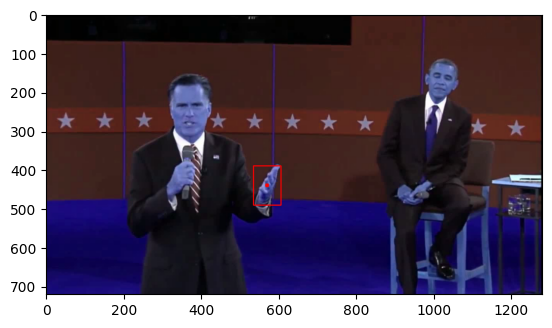

In [250]:
img1 = frames[0].copy()
plt.imshow(img1)
# img1 = cv2.rectangle(img1, (520,375), (623, 504), color=[255,0,0], thickness=5)
# img1 = draw_bounding_box(img1, *get_inital_hand_center_and_sizes())
x,y = 535, 390
w,h = 70, 100
x = x+w//2
y = y+h//2
img1 = draw_bounding_box(img1, x,y,w,h)
plt.imshow(img1)